In [9]:
from value import Value
from typing import List
import random
from draw import draw_dot


class Neuron:

    def __init__(self, nin: int):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x: List[float]):
        # w * x + b
        # print(list(zip(self.w, x))) # pairing the input element with value and output as a tunple list
        act = sum([wi * xi for (wi, xi) in zip(self.w, x)], self.b)
        out = act.tanh()
        return out


def neuronExample():
    x = [2.0, 3.0]
    n = Neuron(2)
    # run the `__call__` function
    # zip(self.w,x)  ==> create a tuple for the element with same index then output to a list
    # like [(Value(data=0.31302155296131984, label=), 2.0), (Value(data=-0.4261160607177399, label=), 3.0)]
    print(n(x))


neuronExample()

Value(data=0.1566942500252338, label=)


![mlp](./images/layers.jpg)

In [10]:
class Layer:
    def __init__(self, nin: int, nout: int):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x: int):
        outs = [n(x) for n in self.neurons]
        # return outs
        # output beautify
        return outs[0] if len(outs) == 1 else outs


def layerExample():
    x = [2.0, 3.0]
    l = Layer(2, 3)
    print(l(x))


layerExample()

[Value(data=0.9344800716633396, label=), Value(data=0.9069995943595265, label=), Value(data=0.9657110611166457, label=)]


Value(data=0.6594768463798301, label=)


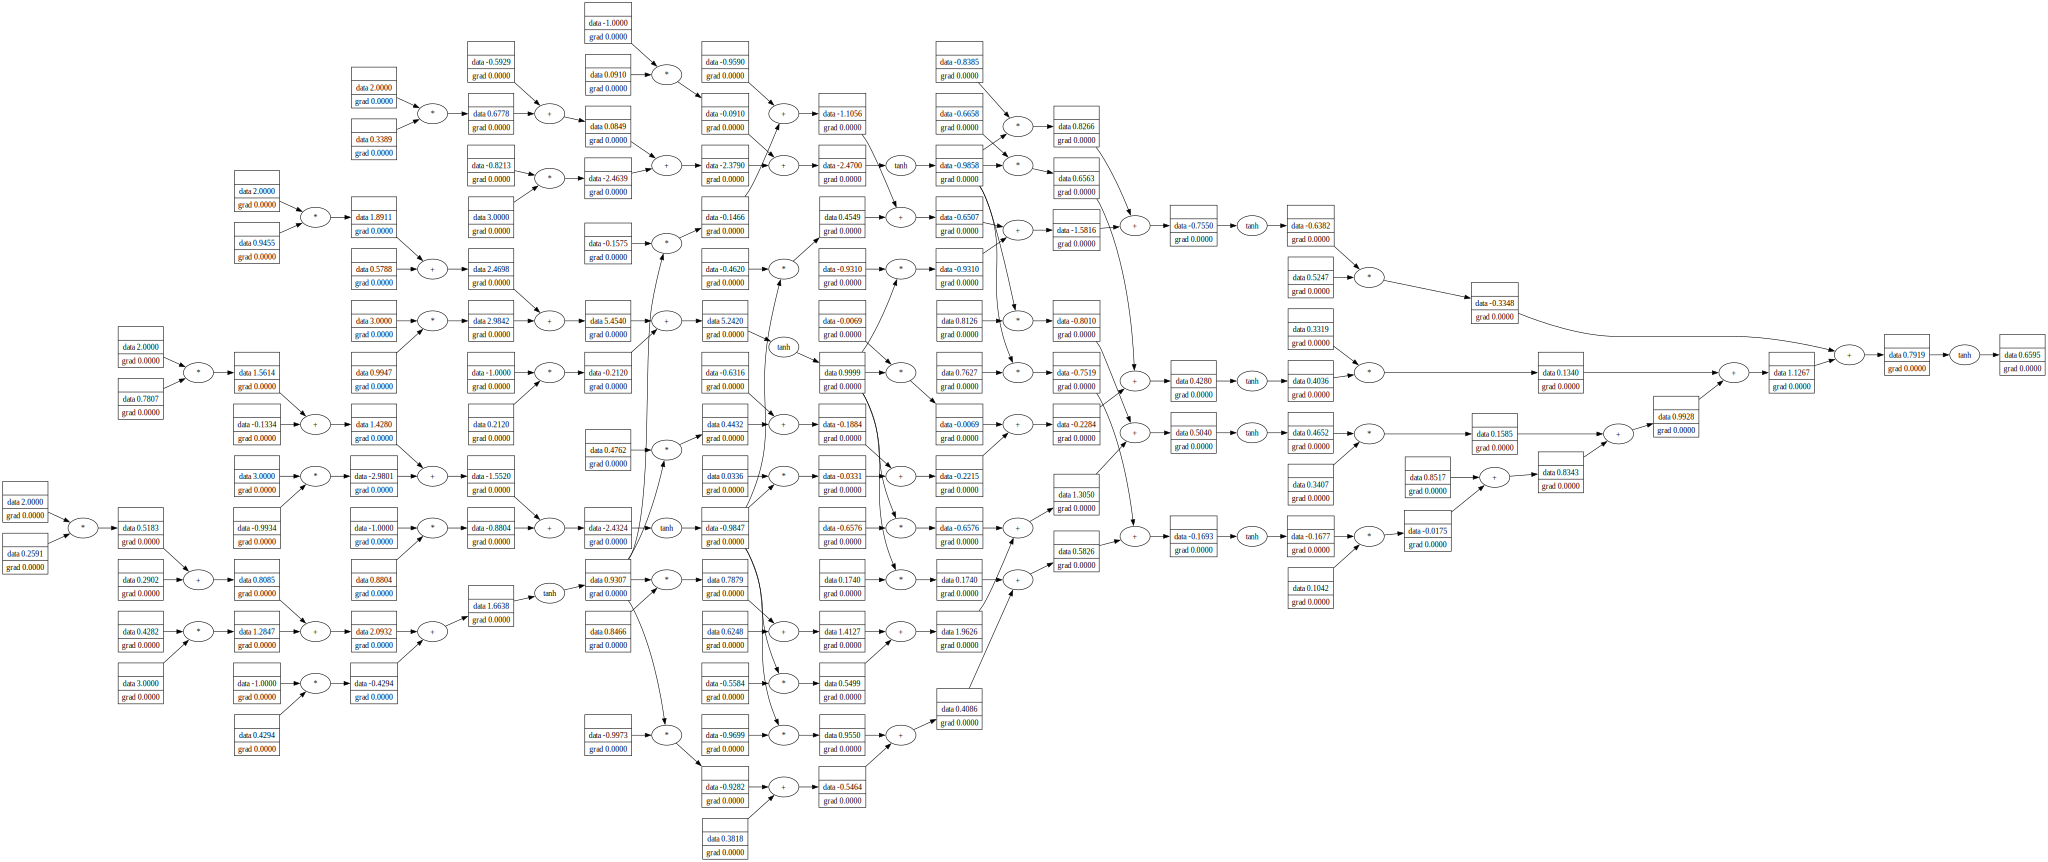

In [ ]:
class MLP:
    # nin number of neurons in the input layer , nouts: each number stands for the number of neurons in each layer
    def __init__(self, nin: int, nouts: List[int]):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


def layerExample():
    x = [2.0, 3.0, -1.0]
    m = MLP(
        3, [4, 4, 1]
    )  # 3 neurons in input layers, 4 neurons first & second hidden layer, 1 neuron in the output layer
    out = m(x)
    print(out)
    return out

layerExample()

# draw_dot(layerExample())